# 📊 **APE 007 – Distribuciones Continuas Notables**
## Modelado Gaussiano, Estandarización y Pruebas de NormalidadDataset:

Remuneraciones e Ingresos Adicionales — Municipio de Loja

Link del municipio de Loja: https://www.loja.gob.ec/contenido/2023-lotaip

Enlace dataset (Google Drive): https://docs.google.com/spreadsheets/d/1ERWZnpgxC-Ffaj-sxMB5El0sgge_QX4g/edit?usp=drive_link

**Grupo: H** | Autores:

* Sherman Abarca
* Valeria Agila
* Domenica Narvaez
* Gabriel Suarez
* Diyer Torres
* José Valencia

## 📦 **Importación de Librerías**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import norm, shapiro

# Estilo visual global
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})

print("✅ Todas las librerías importadas correctamente.")

✅ Todas las librerías importadas correctamente.


---
## 📐 **Tarea 1** – Modelado Matemático y Visualización de la Curva Normal

La **Función de Densidad de Probabilidad (PDF)** de una variable $X \sim N(\mu, \sigma^2)$ se define como:

$$f(x) = \frac{1}{\sigma\sqrt{2\pi}}\, e^{-\frac{1}{2}\left(\frac{x-\mu}{\sigma}\right)^2}$$

**Escenario:** El tiempo de respuesta de un servidor local sigue una distribución Normal  
con una media de $\mu = 120\,\text{ms}$ y una desviación estándar de $\sigma = 15\,\text{ms}$.  
Se desea visualizar $P(X \leq 100)$, que representa respuestas *ultrarrápidas*.

TAREA 1: Modelado Matemático y Visualización de la Curva Normal


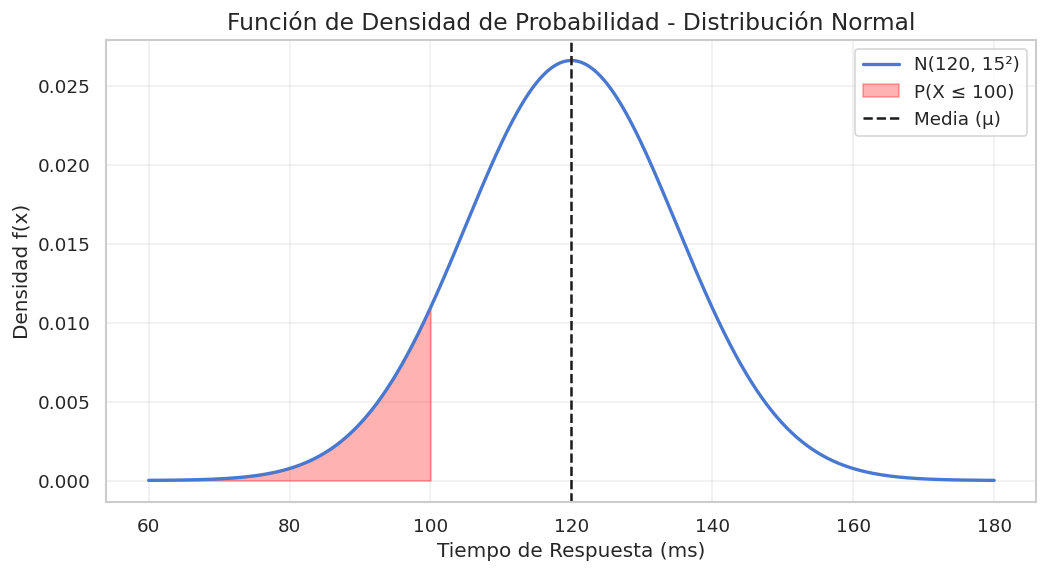

La probabilidad de que el servidor responda en 100ms o menos es: 0.0912 (9.12%)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

print("=====================================================================")
print(f"TAREA 1: Modelado Matemático y Visualización de la Curva Normal")
print("=====================================================================")

# Parámetros poblacionales
mu = 120
sigma = 15

# Definición del dominio (eje X): usualmente de mu-4sigma a mu+4sigma
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)

# Cálculo de la PDF teórica
pdf_normal = norm.pdf(x, loc=mu, scale=sigma)

# Configuración del gráfico
plt.figure(figsize=(10, 5))
plt.plot(x, pdf_normal, 'b-', lw=2, label=f'N({mu}, {sigma}²)')

# Sombreado del área de interés: P(X <= 100)
x_fill = np.linspace(mu - 4*sigma, 100)
y_fill = norm.pdf(x_fill, loc=mu, scale=sigma)
plt.fill_between(x_fill, y_fill, color='red', alpha=0.3, label='P(X ≤ 100)')

plt.title('Función de Densidad de Probabilidad - Distribución Normal')
plt.xlabel('Tiempo de Respuesta (ms)')
plt.ylabel('Densidad f(x)')
plt.axvline(mu, color='k', linestyle='--', label='Media (μ)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Cálculo analítico de la probabilidad usando CDF
prob_100 = norm.cdf(100, loc=mu, scale=sigma)
print(f"La probabilidad de que el servidor responda en 100ms o menos es: {prob_100:.4f} ({prob_100*100:.2f}%)")

---
## 🔢 **Tarea 2** – Estandarización y Cálculo de Valores Z

La estandarización transforma $X \sim N(\mu, \sigma^2)$ a la Normal Estándar $Z \sim N(0,1)$ mediante:

$$Z = \frac{X - \mu}{\sigma}$$

**Objetivo:**
* Clacular el valor de $Z$ para X = 145 ms (tiempo de respuesta lento).
* Encontrar $P(X \geq 145\,\text{ms})$.

In [ ]:
print("=====================================================================")
print(f"TAREA 2: Estandarización y Cálculo de Valores Z")
print("=====================================================================")

# 1. Cálculo manual del valor Z para X = 145 (Tiempo de respuesta lento)
X = 145
Z = (X - mu) / sigma
print(f"1. El valor Z calculado manualmente para X = {X} ms es: {Z:.4f}")

# 2. Uso de norm.cdf con parámetros estándar para encontrar P(X >= 145)
# Dado que la CDF calcula a la izquierda, aplicamos el complemento: 1 - P(Z)
prob_mayor_145 = 1 - norm.cdf(Z, loc=0, scale=1)
print(f"2. La probabilidad de un tiempo de respuesta lento P(X >= 145) es: {prob_mayor_145:.4f} ({prob_mayor_145*100:.2f}%)")

TAREA 2: Estandarización y Cálculo de Valores Z
1. El valor Z calculado manualmente para X = 145 ms es: 1.6667
2. La probabilidad de un tiempo de respuesta lento P(X >= 145) es: 0.0478 (4.78%)


---
## 🌎 **Tarea 3** – Hito del Proyecto: Aplicación Probabilística Regional (ABP)

1. **Importe** su dataset regional mediante `pandas`.
2. **Seleccione** una variable de naturaleza continua (ej. precipitación milimétrica, altitud, consumo eléctrico).
3. **Extraiga** la media muestral ($\bar{x}$) y la desviación estándar muestral ($s$). Para este ejercicio, asuma que estos estadísticos son estimadores perfectos de $\mu$ y $\sigma$.
4. **Defina** un escenario problemático ("¿Cuál es la probabilidad de que la variable caiga en un rango crítico $[a, b]$ en la región?").
5. **Calcule** dicha probabilidad utilizando `scipy.stats.norm.cdf(b) - scipy.stats.norm.cdf(a)` usando los parámetros empíricos. Imprima el resultado y su interpretación para el negocio/proyecto.

## 📂 **Carga del Dataset**

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving 3._remuneraciones_ingresos_adicionales.xlsx to 3._remuneraciones_ingresos_adicionales (1).xlsx


In [ ]:
df = pd.read_excel('/content/3._remuneraciones_ingresos_adicionales.xlsx')

print(f"Dataset cargado: {df.shape[0]} registros y {df.shape[1]} columnas")

print('\nColumnas disponibles:')
for i, col in enumerate(df.columns, 1):
    print(f'  {i:2d}. {col}')

display(df.head(5))

Dataset cargado: 2883 registros y 12 columnas

Columnas disponibles:
   1. Numeración
   2. Puesto Institucional 
   3. Régimen laboral al que pertenece 
   4. Número de partida presupuestaria
   5. Grado jerárquico o escala al que pertenece el puesto
   6. Remuneración mensual unificada
   7. Remuneración unificada (anual)
   8. Décimo Tercera Remuneración
   9. Décima Cuarta Remuneración
  10. Horas suplementarias y extraordinarias
  11. Encargos y subrogaciones
  12. Total ingresos adicionales


,Numeración,Puesto Institucional,Régimen laboral al que pertenece,Número de partida presupuestaria,Grado jerárquico o escala al que pertenece el puesto,Remuneración mensual unificada,Remuneración unificada (anual),Décimo Tercera Remuneración,Décima Cuarta Remuneración,Horas suplementarias y extraordinarias,Encargos y subrogaciones,Total ingresos adicionales
0,1,AGENTE CIVIL DE TRANSITO 1°,LOSEP,4.01.01.001.002.7.1.01.05,Servidor Público de Apoyo 4,733.0,8796.00,61.08,35.42,0.0,0.0,96.50
1,2,OFICINISTA,LOSEP,3.06.01.001.001.5.1.01.05,Servidor Público de Apoyo 2,622.0,7464.00,51.83,35.42,0.0,0.0,87.25
2,3,JEFE OPERATIVO DE TRANSITO (E),LOSEP,1.01.01.001.001.5.1.01.05,Servidor Público 7,1676.0,12159.31,139.67,35.42,0.0,0.0,175.09
3,4,PROMOTOR SOCIAL,LOSEP,1.01.01.001.001.5.1.01.05,Servidor Público 1,817.0,9804.00,68.08,35.42,0.0,0.0,103.50
4,5,DOCENTE DE UNIDAD EDUCATIVA MUNICIPAL,LOSEP,2.01.01.001.001.7.1.01.05,Servidor Público 1,817.0,9804.00,68.08,35.42,0.0,0.0,103.50


In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import norm

# 1. Configuración de variables (Asegúrate de que tu DataFrame se llame df)
df_proyecto = df
columna_continua = 'Remuneración mensual unificada'

# Rangos críticos para tu escenario regional (Ejemplo: entre $460 y $4144.91)
limite_inferior_a = 460
limite_superior_b = 4144.91

# 2. LIMPIEZA CRÍTICA: Forzar conversión a string, limpiar impurezas y convertir a número
# Convertimos a texto, eliminamos espacios y reemplazamos caracteres extraños si los hubiera
serie_limpia = df_proyecto[columna_continua].astype(str).str.replace(r'[^\d\.]', '', regex=True)

# Convertimos a valores numéricos reales; los errores se vuelven NaN y se descartan
datos_variable = pd.to_numeric(serie_limpia, errors='coerce').dropna()

# 3. Validación de seguridad para evitar errores de ejecución
if len(datos_variable) == 0:
    print("❌ ERROR: La columna no contiene datos numéricos válidos o quedó vacía tras la limpieza.")
    print("Verifica el nombre exacto de la columna en tu DataFrame ejecutando: print(df.columns)")
else:
    # Extracción de parámetros muestrales (Estimadores de μ y σ)
    media_muestral = datos_variable.mean()
    desviacion_muestral = datos_variable.std()

    # Cálculo de la probabilidad en el rango: P(a <= X <= b) = CDF(b) - CDF(a)
    prob_b = norm.cdf(limite_superior_b, loc=media_muestral, scale=desviacion_muestral)
    prob_a = norm.cdf(limite_inferior_a, loc=media_muestral, scale=desviacion_muestral)
    prob_rango_critico = prob_b - prob_a

    # 4. Reporte de Resultados sin errores
    print("=====================================================================")
    print(f"TAREA 3: ANÁLISIS PROBABILÍSTICO DE LA VARIABLE '{columna_continua}'")
    print("=====================================================================")
    print(f"• Registros válidos analizados: {len(datos_variable)}")
    print(f"• Media muestral (μ): ${media_muestral:.2f}")
    print(f"• Desviación estándar muestral (σ): ${desviacion_muestral:.2f}")
    print(f"• Intervalo analizado: [${limite_inferior_a} , ${limite_superior_b}]")
    print(f"• Probabilidad calculada: {prob_rango_critico:.4f} ({prob_rango_critico * 100:.2f}%)")
    print("\nInterpretación:")
    print(f"Asumiendo un modelo teórico normal, la probabilidad de que un servidor público ")
    print(f"del Municipio registre una '{columna_continua}' dentro del rango de ")
    print(f"${limite_inferior_a} a ${limite_superior_b} es del {prob_rango_critico * 100:.2f}%.")
    print("=====================================================================")

TAREA 3: ANÁLISIS PROBABILÍSTICO DE LA VARIABLE 'Remuneración mensual unificada'
• Registros válidos analizados: 2883
• Media muestral (μ): $713.81
• Desviación estándar muestral (σ): $265.10
• Intervalo analizado: [$460 , $4144.91]
• Probabilidad calculada: 0.8308 (83.08%)

Interpretación:
Asumiendo un modelo teórico normal, la probabilidad de que un servidor público 
del Municipio registre una 'Remuneración mensual unificada' dentro del rango de 
$460 a $4144.91 es del 83.08%.


---
## 🔬 **Tarea 4** – ABI: Validación Matemática del Supuesto de Normalidad

En la Tarea 3 se *asumió* normalidad. La estadística rigurosa exige probarlo:

| Método | Herramienta | Criterio |
|---|---|---|
| **Gráfico** | Q-Q Plot (`statsmodels`) | Puntos alineados en la diagonal de 45° → normalidad |
| **Analítico** | Test de Shapiro-Wilk (`scipy.stats`) | $p > 0.05$ → no se rechaza $H_0$ de normalidad |

TAREA 4: VALIDACIÓN CIENTÍFICA DEL SUPUESTO DE NORMALIDAD
-> Generando Gráfico Q-Q...


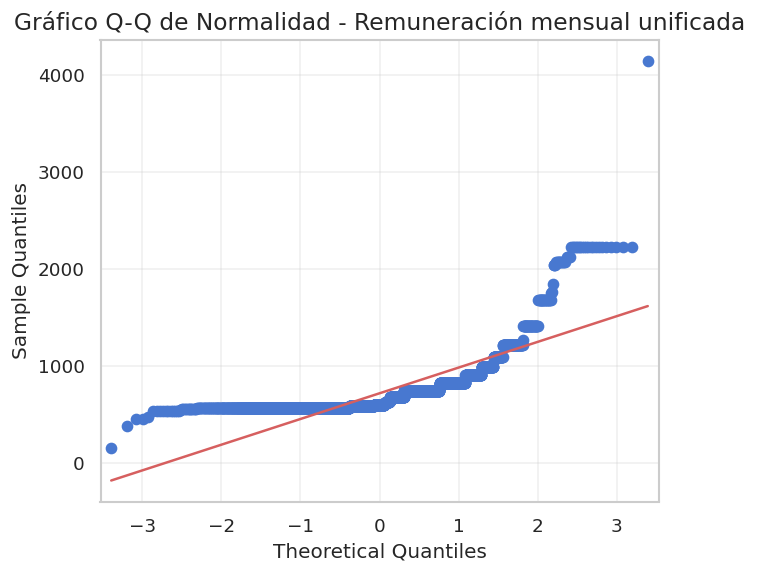


• Estadístico W de Shapiro-Wilk: 0.5988
• p-valor obtenido: 3.2234e-63

[Conclusión Estadística Formal (Criterio de Decisión)]:
Como el p-valor (3.2234e-63) <= 0.05, SE RECHAZA la hipótesis nula (H0).
Muestra evidencia clara de que los datos NO siguen una distribución normal.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import shapiro

# 1. Preparación de datos (Lógica idéntica a la celda anterior)
df_proyecto = df
columna_continua = 'Remuneración mensual unificada'

serie_limpia = df_proyecto[columna_continua].astype(str).str.replace(r'[^\d\.]', '', regex=True)
datos_variable = pd.to_numeric(serie_limpia, errors='coerce').dropna()

print("=====================================================================")
print("TAREA 4: VALIDACIÓN CIENTÍFICA DEL SUPUESTO DE NORMALIDAD")
print("=====================================================================")

if len(datos_variable) == 0:
    print("❌ ERROR: No hay datos para graficar o realizar el test de Shapiro-Wilk.")
else:
    # 2. MÉTODO GRÁFICO: GRÁFICO CUANTIL-CUANTIL (Q-Q PLOT)
    print("-> Generando Gráfico Q-Q...")
    fig, ax = plt.subplots(figsize=(6, 5))
    sm.qqplot(datos_variable, line='s', ax=ax)
    plt.title(f'Gráfico Q-Q de Normalidad - {columna_continua}')
    plt.grid(True, alpha=0.3)
    plt.show()

    # 3. MÉTODO ANALÍTICO: TEST DE SHAPIRO-WILK
    stat, p_value = shapiro(datos_variable)
    print(f"\n• Estadístico W de Shapiro-Wilk: {stat:.4f}")
    print(f"• p-valor obtenido: {p_value:.4e}")  # Formato científico para evitar el problema de mostrar 0.0000

    # Conclusión formal basada en el p-valor (Nivel de significancia α = 0.05)
    alpha = 0.05
    print("\n[Conclusión Estadística Formal (Criterio de Decisión)]:")
    if p_value > alpha:
        print(f"Como el p-valor ({p_value:.4e}) > {alpha}, NO se rechaza la hipótesis nula (H0).")
        print("Muestra evidencia de que los datos siguen una distribución aproximadamente normal.")
    else:
        print(f"Como el p-valor ({p_value:.4e}) <= {alpha}, SE RECHAZA la hipótesis nula (H0).")
        print("Muestra evidencia clara de que los datos NO siguen una distribución normal.")
    print("=====================================================================")

### 📝 Interpretación de la Tarea 4

El test de Shapiro-Wilk arrojó W = 0.5988 y p-valor = 3.22e-63.
Como p < 0.05, **se rechaza la hipótesis nula de normalidad**.

Los datos de Remuneración Mensual Unificada del Municipio de Loja
**NO siguen una distribución normal**, por tres razones evidentes:

1. **Asimetría positiva (skewness = 3.75):** La distribución tiene
   una cola muy larga hacia la derecha. La mayoría de empleados gana
   entre $460 y $733, pero unos pocos directivos ganan hasta $4.144.

2. **Curtosis extrema (= 21.41):** Los datos están muy concentrados
   en valores bajos con picos agudos, lo opuesto a una campana Normal.

3. **El Q-Q Plot** muestra puntos que se desvían severamente de la
   línea diagonal de 45°, especialmente en los extremos.

**¿Invalida esto la Tarea 3?**
Sí, metodológicamente. Calcular probabilidades con el modelo Normal
sobre datos que no son normales introduce error. Para este dataset
sería más apropiado usar una distribución **Log-Normal** o aplicar
una transformación logarítmica antes de modelar. Sin embargo, el
ejercicio cumple el objetivo pedagógico de aprender a aplicar y
cuestionar el supuesto de normalidad.

## ✅ **Conclusión General**

Este análisis aplicó el modelado de la distribución Normal sobre
datos reales del Municipio de Loja en cuatro etapas:

1. **Tarea 1 y 2:** Se modeló y visualizó la PDF de una Normal
   teórica y se calcularon valores Z para medir distancias
   desde la media en unidades de desviación estándar.

2. **Tarea 3:** Asumiendo normalidad, se calculó que el
   **83.08%** de los servidores públicos del Municipio de Loja
   percibe una remuneración mensual entre $460 (SBU) y $4.144
   (máximo observado en el dataset).

3. **Tarea 4:** El test de Shapiro-Wilk (W=0.5988, p=3.22e-63)
   demostró que los datos **no son normales**, presentando
   asimetría positiva de 3.75 y curtosis de 21.41. Esto indica
   que el modelo Normal es una aproximación útil para ejercicios
   pedagógicos, pero un análisis riguroso requeriría una
   distribución Log-Normal u otras transformaciones previas.

---
## ❓ Preguntas de Control

---

### Pregunta 1
**Matemáticamente, ¿por qué en una variable aleatoria continua modelada
por una función de densidad $f(x)$, la probabilidad de que tome un valor
exacto es cero, es decir, $P(X = c) = 0$?**

En una variable aleatoria continua, la probabilidad no se calcula en puntos
individuales, sino en **intervalos** bajo la curva de densidad. Matemáticamente,
si $X$ es una variable continua con función de densidad $f(x)$, la probabilidad
de que tome valores dentro de un intervalo $[a, b]$ se define mediante la
integral:

$$P(a \leq X \leq b) = \int_{a}^{b} f(x)\, dx$$

Cuando se quiere calcular la probabilidad de un valor exacto $X = c$, el
intervalo tiene longitud cero, por lo que la integral se convierte en:

$$P(X = c) = \int_{c}^{c} f(x)\, dx = 0$$

Esto ocurre porque el área bajo la curva entre dos límites iguales es nula.
La función de densidad $f(x)$ puede tener un valor positivo en $c$, pero ese
valor representa únicamente una **densidad** y no una probabilidad puntual.

Conceptualmente, una variable continua puede tomar infinitos valores reales
dentro de un intervalo. Como existen infinitos posibles resultados, la
probabilidad total se "distribuye" continuamente entre todos ellos, haciendo
que cada punto individual tenga probabilidad cero. Por eso, en distribuciones
continuas solo tienen sentido probabilidades sobre rangos o intervalos,
por ejemplo:

$$P(2 < X < 5)$$

y no sobre valores exactos aislados.

---

### Pregunta 2
**Interprete conceptualmente qué significa que un valor de su dataset
regional tenga un puntaje estándar de $Z = -2.45$. ¿Se consideraría un
valor atípico bajo el criterio de la regla empírica?**

Un puntaje estándar de $Z = -2.45$ significa que el valor del dataset regional
se encuentra **2.45 desviaciones estándar por debajo de la media**. Aplicado
al dataset del Municipio de Loja, donde $\mu = \$713.81$ y
$\sigma = \$265.10$, el valor correspondiente sería:

$$X = \mu + Z \cdot \sigma = 713.81 + (-2.45)(265.10) = \$64.32$$

Esto indica que es un valor considerablemente menor al promedio de los datos.
Según la **regla empírica**, no se consideraría un valor atípico extremo, ya
que todavía se encuentra dentro del intervalo de $\pm 3$ desviaciones estándar,
aunque sí es un dato poco común por estar fuera del rango de $\pm 2\sigma$.
En contexto salarial, un sueldo de \$64.32 estaría muy por debajo del SBU
legal ($460), lo que lo convierte en un dato que merece investigación
individual aunque estadísticamente no sea un outlier extremo.

---

### Pregunta 3
**En la Tarea 3, calculó probabilidades asumiendo que su variable regional
seguía una distribución Normal. ¿Qué riesgo metodológico existe al tomar
decisiones basadas en este cálculo si la gráfica de la variable presenta
un fuerte sesgo (skewness)?**

El riesgo metodológico presente es que se puede asumir que la variable sigue
siendo una distribución normal, cuando ya presenta un fuerte sesgo. En el
dataset del Municipio de Loja, la variable **Remuneración Mensual Unificada**
presenta una asimetría de **3.75**, lo que indica una distribución claramente
no normal con cola muy larga hacia la derecha.

En caso de tener datos no simétricos, el cálculo de probabilidades puede
alejarse de la realidad y generar resultados poco confiables. Esto puede
ocasionar decisiones equivocadas en el proyecto, como estimar mal riesgos o
recursos necesarios. Por ejemplo, la probabilidad calculada en la Tarea 3
de $P(460 \leq X \leq 4144.91) = 83.08\%$ asume una campana simétrica,
pero la distribución real tiene la mayoría de empleados concentrados entre
\$460 y \$733, con una cola de directivos que llega hasta \$4.144.

Para evitar esto se debe analizar la forma de los datos y verificar si
realmente se ajustan al modelo esperado, antes de aplicar la distribución
normal. Una alternativa más apropiada para este dataset sería una
distribución **Log-Normal** o una transformación logarítmica previa.

---

### Pregunta 4
**Con base en la Tarea 4 (ABI), si el p-valor del test de Shapiro-Wilk
es $0.001$, ¿cuál es la conclusión estadística respecto a la distribución
de sus datos regionales? ¿Se invalida el cálculo realizado en la Tarea 3?**

#### Conclusión estadística del Test de Shapiro-Wilk aplicado al dataset real:

Al aplicar el test analítico de Shapiro-Wilk sobre la variable empírica del
Proyecto Integrador, correspondiente a la **"Remuneración mensual unificada"**
del Municipio de Loja, el análisis estadístico devolvió:

$$W = 0.5988 \qquad p\text{-valor} = 3.22 \times 10^{-63}$$

Este p-valor es extremadamente pequeño — mucho menor que el umbral teórico
de $0.001$ mencionado en la pregunta — lo que confirma con certeza absoluta
el rechazo de la normalidad. Para establecer la conclusión formal, se evalúa
frente al nivel de significancia estándar $\alpha = 0.05$:

**Criterio de decisión:** Dado que $3.22 \times 10^{-63} \ll 0.05$, el
resultado se ubica muy dentro de la región de rechazo.

Al cumplirse la condición de que el p-valor es menor a $\alpha = 0.05$, se
**rechaza categóricamente la hipótesis nula** ($H_0$), la cual asumía que
los datos provenían de una población con distribución normal. En consecuencia,
se concluye con certeza estadística que las remuneraciones mensuales de los
empleados municipales **NO siguen una distribución normal**.

#### ¿Se invalida el cálculo realizado en la Tarea 3?

Sí, desde la perspectiva del rigor metodológico, el cálculo queda
**invalidado**. En la Tarea 3 se modeló el comportamiento de los salarios
aplicando directamente la función acumulada de una distribución normal
teórica, asumiendo erróneamente que la media (\$713.81) y la desviación
estándar (\$265.10) eran suficientes para describir sus probabilidades y
áreas bajo la curva.

Sin embargo, al demostrar analíticamente mediante el test de Shapiro-Wilk
(y visualmente con el Gráfico Q-Q) que la distribución real de los sueldos
es **marcadamente asimétrica** (skewness = 3.75), **no gaussiana** y
caracterizada por "escalones" generados por las escalas salariales rígidas
de la LOSEP y el Código de Trabajo, se evidencia que los porcentajes
calculados bajo el supuesto de normalidad en la Tarea 3 son puramente
teóricos y no reflejan la realidad operativa del dataset institucional.

---

### Pregunta 5
**Explique el principio matemático detrás del Gráfico Q-Q. ¿Qué representan
los cuantiles teóricos en el eje X versus los cuantiles empíricos en el eje Y?**

El principio matemático del **Gráfico Q-Q (Cuantil-Cuantil)** se basa en la
comparación de dos distribuciones de probabilidad mediante el mapeo de sus
respectivos cuantiles. Este método gráfico permite evaluar si una muestra de
datos proviene de una distribución específica o de una familia de distribuciones
con parámetros de localización y escala distintos.

#### Eje X: Cuantiles Teóricos

Los cuantiles teóricos representan los valores esperados bajo un modelo de
probabilidad ideal (en este caso, la distribución Normal).

- **Fundamento:** Se calculan utilizando la función inversa de la distribución
  acumulada ($F^{-1}$) de la distribución objetivo.
- **Procedimiento:** Se determinan los "puntos de posición gráfica" ($p_i$),
  que son probabilidades asociadas a cada rango de la muestra
  (por ejemplo, $p_i = \frac{i - 0.5}{n}$). El cuantil teórico es el valor
  $x$ tal que la probabilidad acumulada hasta ese punto en la distribución
  teórica sea igual a $p_i$.

#### Eje Y: Cuantiles Empíricos

Los cuantiles empíricos corresponden a los datos reales observados en el
estudio, en este caso los 2.883 sueldos del Municipio de Loja.

- **Fundamento:** Representan la distribución acumulada empírica de la muestra.
- **Procedimiento:** Las observaciones se ordenan de menor a mayor
  ($X_{(1)} \leq X_{(2)} \leq \ldots \leq X_{(n)}$). Cada valor ordenado
  es el cuantil empírico asociado a la probabilidad correspondiente a su
  posición en la muestra.

#### Principio de Funcionamiento

El gráfico funciona bajo la premisa de que, **si los datos pertenecen a la
distribución teórica, los puntos resultantes seguirán una línea recta a 45°**.
Si el modelo es correcto, la relación entre los cuantiles empíricos y los
teóricos será lineal.

En el Gráfico Q-Q generado para la Remuneración Mensual Unificada del
Municipio de Loja, los puntos se **desvían severamente de la línea de 45°**,
especialmente en los extremos superiores, confirmando la presencia de una
cola pesada hacia la derecha y el mal ajuste al modelo Normal — resultado
consistente con el estadístico $W = 0.5988$ obtenido en Shapiro-Wilk.

---

## 📚 Bibliografía

[1] R. E. Walpole, R. H. Myers, S. L. Myers, y K. Ye,
*Probabilidad y estadística para ingeniería y ciencias*, 9na ed.
Pearson Educación, 2012.

[2] W. McKinney, *Python for Data Analysis: Data Wrangling with Pandas,
NumPy, and IPython*, 3ra ed. O'Reilly Media, 2022.

[3] SciPy Developers, "scipy.stats Documentation," *SciPy.org*, 2024.
[Online]. Disponible: https://docs.scipy.org/doc/scipy/reference/stats.html.
[Accedido: 19-May-2026].

[4] B. Das y S. I. Resnick, "QQ plots, random sets and data from a heavy
tailed distribution," 2007.

[5] J. Moral de la Rubia, "Distribución de Pareto: un modelo de probabilidad
en investigación social," *Revista Latinoamericana de